### Libraries

In [9]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime, timedelta

import torch
import torchinfo
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

from pathlib import Path
Root = Path('.').absolute().parent
# DATA = Root/ r'C:\Users\Admin\Projects\ML Projects\ManipDetect\data'
DATA = Root/ r'C:\Users\krishnadas\Projects\ML Projects\ManipDetect\data'

In [34]:
def prepare_lstm_sequences(df, sequence:str, sequence_name:str, sequence_length:int):
    """Prepare sequences for LSTM training
    Choose the correct df based on the sequence type
    sequence: 'daily', 'hourly', or 'weekly'
    sequence_name: 'date', 'hour', or 'week'
    """
    assert sequence in ['daily', 'hourly', 'weekly'], \
        "Invalid sequence type. Choose from 'daily', 'hourly', or 'weekly'."
    assert sequence_name in ['date', 'hour', 'week'], \
        "Invalid sequence name. Choose from 'date', 'hour', or 'week'."
    assert sequence_length in [7, 24, 4], \
        "Invalid sequence length. Choose from 7 (daily), 24 (hourly), or 4 (weekly)."
    try:
        # df = label_manipulation_periods_sequence(df, sequence, sequence_name)
        df = df.sort_values(sequence_name).reset_index(drop=True)
        # Select feature columns (exclude date and target)
        feature_cols = [col for col in df.columns 
                        if col not in [sequence_name, 'is_manipulation','date', 'week']]
        # Create sequences
        X, y = [], []
        
        for i in range(sequence_length, len(df)):
            # Use previous 7 days to predict current day
            X.append(df[feature_cols].iloc[i-sequence_length:i].values)
            y.append(df['is_manipulation'].iloc[i])
        
    except Exception as e:
        print(f"Error preparing sequences: {e}")
        return None, None, None
    
    return np.array(X), np.array(y), feature_cols

In [2]:
# load the data
hourly_data = pd.read_pickle(DATA/'hourly_data.pkl')


In [44]:
# Simulated time series data: 100 samples, 5 features per sample
np.random.seed(42)
n_samples = 100
n_features = 5
X = np.random.randn(n_samples, n_features)  # Feature matrix
y = np.zeros(n_samples)  # Labels: 0 (majority), 1 (minority)
y[10:20] = 1  # Minority class for samples 10-19 (10% minority)

In [ ]:
minority_df = hourly_data[hourly_data['is_manipulation'] == 1]
majority_df = hourly_data[hourly_data['is_manipulation'] == 0]

# Calculate how many times to duplicate minority samples
factor = majority_df.shape[0] // minority_df.shape[0]

# Duplicate the minority class
minority_oversampled = pd.concat([minority_df] * factor, ignore_index=True)

# Combine back into a single DataFrame
df_oversampled = pd.concat([hourly_data, minority_oversampled], ignore_index=True)

# shuffle rows
# df_oversampled = df_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)
# Sort by date and hour
df_oversampled = df_oversampled.sort_values(by=['date', 'hour']).reset_index(drop=True)

# Check new distribution
print(df_oversampled['is_manipulation'].value_counts(normalize=True))


is_manipulation
1    0.507202
0    0.492798
Name: proportion, dtype: float64


In [35]:
X_hourly, y_hourly, feature_cols_hourly = prepare_lstm_sequences(df_oversampled, sequence='hourly', 
                                                                sequence_name='hour',
                                                                sequence_length=24)

### Hierarchical Dataset

In [ ]:
# This is not needed if we already have the data set in torch type
class HierarchicalLSTMDataset(Dataset):
    def __init__(self, hourly_data, daily_data, weekly_data, labels):
        self.hourly_data = torch.FloatTensor(hourly_data)
        self.daily_data = torch.FloatTensor(daily_data)
        self.weekly_data = torch.FloatTensor(weekly_data)
        self.labels = labels # labels correspond only to weekly_data

        self.length = min(len(hourly_data), len(daily_data), len(weekly_data))
    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        return {
            'hourly': self.hourly_data[idx],
            'daily': self.daily_data[idx], 
            'weekly': self.weekly_data[idx],
            'label': self.labels[idx]
        }

### Hourly LSTM

In [31]:
class HourlyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, self.hidden_size, self.num_layers, batch_first=True)

        # Attention mechanism to focus on most suspicious hours
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_size,
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )
        # Classification head
        classifier_input_size = hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(), 
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 4, 1),
            nn.Sigmoid()
        )
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        """
        x: (batch_size, sequence_length, input_size) - Hourly features over time
        Returns: 
        - manipulation_prob: (batch_size, 1) - Probability of manipulation
        - attention_weights: (batch_size, num_heads, seq_len, seq_len) if attention is used
        """
        batch_size, seq_len, _ = x.size()
        
        # Initialize hidden states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        # LSTM forward pass - captures temporal dependencies
        lstm_out, (hidden, cell) = self.lstm(x, (h0, c0))
        # lstm_out shape: (batch_size, seq_len, hidden_size)
        
        # Apply attention mechanism if enabled
        attention_weights = None
        if self.attention:
            # Self-attention to focus on most suspicious time periods
            attended_out, attention_weights = self.attention(lstm_out, lstm_out, lstm_out)
            # attended_out shape: (batch_size, seq_len, hidden_size)
            # attention_weights shape: (batch_size, num_heads, seq_len, seq_len)
            
            # Global max pooling to capture strongest manipulation signals
            pooled_features = torch.max(attended_out, dim=1)[0]  # (batch_size, hidden_size)
        else:
            # Use the final hidden state if no attention
            pooled_features = hidden[-1]  # Take the last layer's final hidden state
        
        # Apply dropout
        pooled_features = self.dropout(pooled_features)
        
        # Final classification
        manipulation_prob = self.classifier(pooled_features)
        
        return manipulation_prob, attention_weights


In [32]:
# Create dummy hourly_data
batch_size = 10
hourly_features_size = 17
seq_len = 24

model = HourlyLSTM(input_size=hourly_features_size)
dummy_input = torch.randn(batch_size, seq_len, hourly_features_size)
manipulation_prob, attention_weights = model(dummy_input)
# Print the output shapes
print(f"Input shape: {dummy_input.shape}")
print(f"Hourly embedding shape: {manipulation_prob.shape}")  # Expected: (batch_size, hidden_size // 2)
print(f"Attention weights shape: {attention_weights.shape}")  # Expected: (batch_size, seq_len, seq_len)

torchinfo.summary(model, input_size=(batch_size, seq_len, hourly_features_size))

Input shape: torch.Size([10, 24, 17])
Hourly embedding shape: torch.Size([10, 1])
Attention weights shape: torch.Size([10, 24, 24])


Layer (type:depth-idx)                   Output Shape              Param #
HourlyLSTM                               [10, 1]                   --
├─LSTM: 1-1                              [10, 24, 64]              54,528
├─MultiheadAttention: 1-2                [10, 24, 64]              16,640
├─Dropout: 1-3                           [10, 64]                  --
├─Sequential: 1-4                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 32]                  2,080
│    └─ReLU: 2-2                         [10, 32]                  --
│    └─Dropout: 2-3                      [10, 32]                  --
│    └─Linear: 2-4                       [10, 16]                  528
│    └─ReLU: 2-5                         [10, 16]                  --
│    └─Dropout: 2-6                      [10, 16]                  --
│    └─Linear: 2-7                       [10, 1]                   17
│    └─Sigmoid: 2-8                      [10, 1]                   --
Tot

In [22]:
# from torchviz import make_dot
# from IPython.display import Image, display

# model = WeeklyLSTM(weekly_input_size=10, daily_embedding_size=5)
# weekly_features = torch.randn(32, 4, 10)
# daily_embeddings = torch.randn(32, 4, 5)
# output = model(weekly_features, daily_embeddings)
# dot = make_dot(output, params=dict(model.named_parameters()))
# output_path = "WeeklyLSTM"
# dot.render(output_path, format="png")

# # Display the image in the notebook
# display(Image(filename=output_path + ".png"))

## Training

In [36]:
def prepare_hierarchical_dataset(hourly_data, labels,test_split=0.2, validation_split=0.2, random_seed=42):
    np.random.seed(random_seed)
    # Convert to PyTorch tensors first
    hourly_data = torch.FloatTensor(hourly_data)
    labels = torch.FloatTensor(labels)

    # Calculate split sizes
    total_samples = len(labels)
    test_size = int(test_split * total_samples)
    remaining_samples = total_samples - test_size
    val_size = int(validation_split * remaining_samples)
    train_size = remaining_samples - val_size
    print(f"\nSplit Configuration:")
    print(f"   Total samples: {total_samples}")
    print(f"   Train samples: {train_size} ({train_size/total_samples:.1%})")
    print(f"   Validation samples: {val_size} ({val_size/total_samples:.1%})")
    print(f"   Test samples: {test_size} ({test_size/total_samples:.1%})")
    
    indices = torch.randperm(total_samples)
        
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]
    
    # Train split
    train_hourly = hourly_data[train_indices]
    train_labels = labels[train_indices]
    
    # Validation split
    val_hourly = hourly_data[val_indices]
    val_labels = labels[val_indices]
    
    # Test split
    test_hourly = hourly_data[test_indices]
    test_labels = labels[test_indices]

    # Step 4: Analyze label distribution
    train_pos = train_labels.sum().item()
    val_pos = val_labels.sum().item()
    test_pos = test_labels.sum().item()
    
    print(f"\nLabel Distribution:")
    print(f"   Train: {train_pos}/{len(train_labels)} positive ({train_pos/len(train_labels):.1%})")
    print(f"   Val:   {val_pos}/{len(val_labels)} positive ({val_pos/len(val_labels):.1%})")
    print(f"   Test:  {test_pos}/{len(test_labels)} positive ({test_pos/len(test_labels):.1%})")

    # Step 5: Create metadata
    split_info = {
        'total_samples': total_samples,
        'train_size': train_size,
        'val_size': val_size,
        'test_size': test_size,
        'train_positive_rate': train_pos / len(train_labels),
        'val_positive_rate': val_pos / len(val_labels),
        'test_positive_rate': test_pos / len(test_labels),
        'random_seed': random_seed,
        'original_shapes': {
            'hourly': hourly_data.shape
        }
    }
    
    # Step 6: Package results
    dataset_splits = {
        'train': (train_hourly, train_labels),
        'val': (val_hourly, val_labels),
        'test': (test_hourly, test_labels),
        'info': split_info
    }
    
    print("Dataset preparation completed!")
    return dataset_splits
    

In [37]:
dataset_splits=prepare_hierarchical_dataset(hourly_data=X_hourly, labels=y_hourly)


Split Configuration:
   Total samples: 11640
   Train samples: 7450 (64.0%)
   Validation samples: 1862 (16.0%)
   Test samples: 2328 (20.0%)

Label Distribution:
   Train: 3773.0/7450 positive (50.6%)
   Val:   947.0/1862 positive (50.9%)
   Test:  1196.0/2328 positive (51.4%)
Dataset preparation completed!


In [ ]:
def train_model(train_data, val_data, model_config=None, training_config=None):
    """
    Train the hierarchical LSTM model on prepared datasets
    
    Args:
        train_data: Tuple of (hourly, daily, weekly, labels) for training
        val_data: Tuple of (hourly, daily, weekly, labels) for validation
        model_config: Dictionary with model hyperparameters
        training_config: Dictionary with training hyperparameters
    
    Returns:
        trained_model, training_history
    """
    
    print("🚀 Training Hierarchical LSTM Model")
    print("=" * 40)
    
    # Unpack data
    train_hourly, train_labels = train_data
    val_hourly, val_labels = val_data
    
    # Default configurations
    if model_config is None:
        model_config = {
            'input_size': 17,
            'hidden_size': 64,
            'dropout': 0.2
        }
    
    if training_config is None:
        training_config = {
            'epochs': 20,
            'learning_rate': 0.001,
            'patience': 10,
            'lr_patience': 5,
            'lr_factor': 0.5,
            'verbose': True
        }
    
    print(f"Model Configuration: {model_config}")
    print(f"Training Configuration: {training_config}")
    
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Initialize model
    model = HourlyLSTM(**model_config)
    model.to(device)
    
    print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
    
    # Move data to device
    train_hourly = train_hourly.to(device)
    train_labels = train_labels.to(device)
    
    val_hourly = val_hourly.to(device)
    val_labels = val_labels.to(device)
    
    # Setup training components
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=training_config['learning_rate'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', 
        patience=training_config['lr_patience'], 
        factor=training_config['lr_factor'] 
    )
    
    # Training tracking
    training_history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_precision': [],
        'val_recall': [],
        'val_f1': [],
        'learning_rates': []
    }
    
    # Early stopping setup
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"\nStarting training for {training_config['epochs']} epochs...")
    print("-" * 60)
    
    # Training loop
    for epoch in range(training_config['epochs']):
        # Training phase
        model.train()
        train_predictions, _ = model(train_hourly)
        train_predictions = train_predictions.squeeze()
        
        train_loss = criterion(train_predictions, train_labels)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        train_predicted_classes = (train_predictions > 0.5).float()
        train_accuracy = (train_predicted_classes == train_labels).float().mean()
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_predictions, _ = model(val_hourly)
            val_predictions = val_predictions.squeeze()
            val_loss = criterion(val_predictions, val_labels)
            
            val_predicted_classes = (val_predictions > 0.5).float()
            val_accuracy = (val_predicted_classes == val_labels).float().mean()
            
            # Detailed validation metrics
            val_true_np = val_labels.cpu().numpy()
            val_pred_np = val_predicted_classes.cpu().numpy()
            
            val_precision = precision_score(val_true_np, val_pred_np, zero_division=0)
            val_recall = recall_score(val_true_np, val_pred_np, zero_division=0)
            val_f1 = f1_score(val_true_np, val_pred_np, zero_division=0)
        
        # Update scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store metrics
        training_history['train_loss'].append(train_loss.item())
        training_history['train_accuracy'].append(train_accuracy.item())
        training_history['val_loss'].append(val_loss.item())
        training_history['val_accuracy'].append(val_accuracy.item())
        training_history['val_precision'].append(val_precision)
        training_history['val_recall'].append(val_recall)
        training_history['val_f1'].append(val_f1)
        training_history['learning_rates'].append(current_lr)
        
        # Print progress
        if training_config['verbose']:
            print(f"Epoch {epoch+1:3d}/{training_config['epochs']}: "
                  f"Train Loss={train_loss.item():.4f}, Train Acc={train_accuracy.item():.4f} | "
                  f"Val Loss={val_loss.item():.4f}, Val Acc={val_accuracy.item():.4f}, "
                  f"Val F1={val_f1:.4f}, LR={current_lr:.2e}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            if training_config['verbose']:
                print(f"      → New best validation loss: {val_loss.item():.4f}")
        else:
            patience_counter += 1
            if patience_counter >= training_config['patience']:
                print(f"\nEarly stopping triggered after {epoch+1} epochs")
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model with validation loss: {best_val_loss:.4f}")
    
    print("Training completed successfully!")
    return model, training_history

In [39]:
train_data = dataset_splits['train']
val_data = dataset_splits['val']
test_data = dataset_splits['test']

In [ ]:
def evaluate_model(model, test_data, save_path=None, verbose=True):
    """
    Evaluate the trained model on test data
    
    Args:
        model: Trained model
        test_data: Tuple of (hourly, daily, weekly, labels) for testing
        save_path: Optional path to save the model
        verbose: Whether to print detailed results
    
    Returns:
        Dictionary with evaluation metrics
    """
    
    if verbose:
        print("Evaluating Model on Test Set")
        print("=" * 30)
    test_hourly, test_labels = test_data
    # Ensure data is on the same device as model
    device = next(model.parameters()).device
    test_hourly = test_hourly.to(device)
    test_labels = test_labels.to(device)
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        test_predictions, test_attention = model(test_hourly)
        test_predictions = test_predictions.squeeze()
        
        test_predicted_classes = (test_predictions > 0.5).float()
        test_accuracy = (test_predicted_classes == test_labels).float().mean()
        
        # Convert to numpy for sklearn metrics
        test_true_np = test_labels.cpu().numpy()
        test_pred_np = test_predicted_classes.cpu().numpy()
        test_pred_probs = test_predictions.cpu().numpy()
    
    # Calculate comprehensive metrics
    test_precision = precision_score(test_true_np, test_pred_np, zero_division=0)
    test_recall = recall_score(test_true_np, test_pred_np, zero_division=0)
    test_f1 = f1_score(test_true_np, test_pred_np, zero_division=0)
    
    evaluation_results = {
        'accuracy': test_accuracy.item(),
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': test_f1,
        'predictions': test_pred_probs,
        'true_labels': test_true_np,
        'predicted_classes': test_pred_np,
        'attention_weights': test_attention
    }
    
    if verbose:
        print(f"Test Accuracy: {test_accuracy.item():.4f}")
        print(f"Test Precision: {test_precision:.4f}")
        print(f"Test Recall: {test_recall:.4f}")
        print(f"Test F1-Score: {test_f1:.4f}")
        
        print("\nDetailed Classification Report:")
        print(classification_report(test_true_np, test_pred_np, target_names=['Normal', 'Manipulation']))
        
        print("\nSample Predictions:")
        for i in range(min(5, len(test_labels))):
            true_label = "Manipulation" if test_true_np[i] > 0.5 else "Normal"
            pred_label = "Manipulation" if test_pred_np[i] > 0.5 else "Normal"
            confidence = test_pred_probs[i]
            print(f"   Sample {i+1}: True={true_label:12}, Predicted={pred_label:12} (confidence={confidence:.3f})")
    
    # Save model if requested
    if save_path:
        torch.save(model.state_dict(), save_path)
        if verbose:
            print(f"\nModel saved to: {save_path}")
    
    return evaluation_results

def plot_training_history(history):
    """Plot comprehensive training curves"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss curves
    axes[0, 0].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[0, 1].plot(history['train_accuracy'], 'b-', label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Validation metrics
    axes[1, 0].plot(history['val_precision'], 'g-', label='Precision', linewidth=2)
    axes[1, 0].plot(history['val_recall'], 'orange', label='Recall', linewidth=2)
    axes[1, 0].plot(history['val_f1'], 'purple', label='F1-Score', linewidth=2)
    axes[1, 0].set_title('Validation Metrics')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning rate schedule
    axes[1, 1].semilogy(history['learning_rates'], 'purple', linewidth=2)
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Manipulation'],
                yticklabels=['Normal', 'Manipulation'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [41]:
# Step 2: Train model
trained_model, training_history = train_model(
    dataset_splits['train'], dataset_splits['val'])


🚀 Training Hierarchical LSTM Model
📋 Model Configuration: {'input_size': 17, 'hidden_size': 64, 'dropout': 0.2}
📋 Training Configuration: {'epochs': 20, 'learning_rate': 0.001, 'patience': 10, 'lr_patience': 5, 'lr_factor': 0.5, 'verbose': True}
🖥️  Using device: cpu
🧠 Model initialized with 73,793 parameters

🏋️ Starting training for 20 epochs...
------------------------------------------------------------
Epoch   1/20: Train Loss=0.6926, Train Acc=0.5133 | Val Loss=0.6901, Val Acc=0.5086, Val F1=0.6743, LR=1.00e-03
      → New best validation loss: 0.6901
Epoch   2/20: Train Loss=0.6904, Train Acc=0.5404 | Val Loss=0.6877, Val Acc=0.5086, Val F1=0.6743, LR=1.00e-03
      → New best validation loss: 0.6877
Epoch   3/20: Train Loss=0.6884, Train Acc=0.5799 | Val Loss=0.6848, Val Acc=0.5741, Val F1=0.7049, LR=1.00e-03
      → New best validation loss: 0.6848
Epoch   4/20: Train Loss=0.6851, Train Acc=0.6232 | Val Loss=0.6816, Val Acc=0.7068, Val F1=0.7762, LR=1.00e-03
      → New best v

📊 Evaluating Model on Test Set
🎯 Test Accuracy: 0.9042
📈 Test Precision: 0.8751
📈 Test Recall: 0.9490
📈 Test F1-Score: 0.9105

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.86      0.90      1132
Manipulation       0.88      0.95      0.91      1196

    accuracy                           0.90      2328
   macro avg       0.91      0.90      0.90      2328
weighted avg       0.91      0.90      0.90      2328


🔍 Sample Predictions:
   Sample 1: True=Manipulation, Predicted=Manipulation (confidence=0.727)
   Sample 2: True=Normal      , Predicted=Normal       (confidence=0.428)
   Sample 3: True=Manipulation, Predicted=Manipulation (confidence=0.694)
   Sample 4: True=Normal      , Predicted=Normal       (confidence=0.330)
   Sample 5: True=Manipulation, Predicted=Manipulation (confidence=0.706)


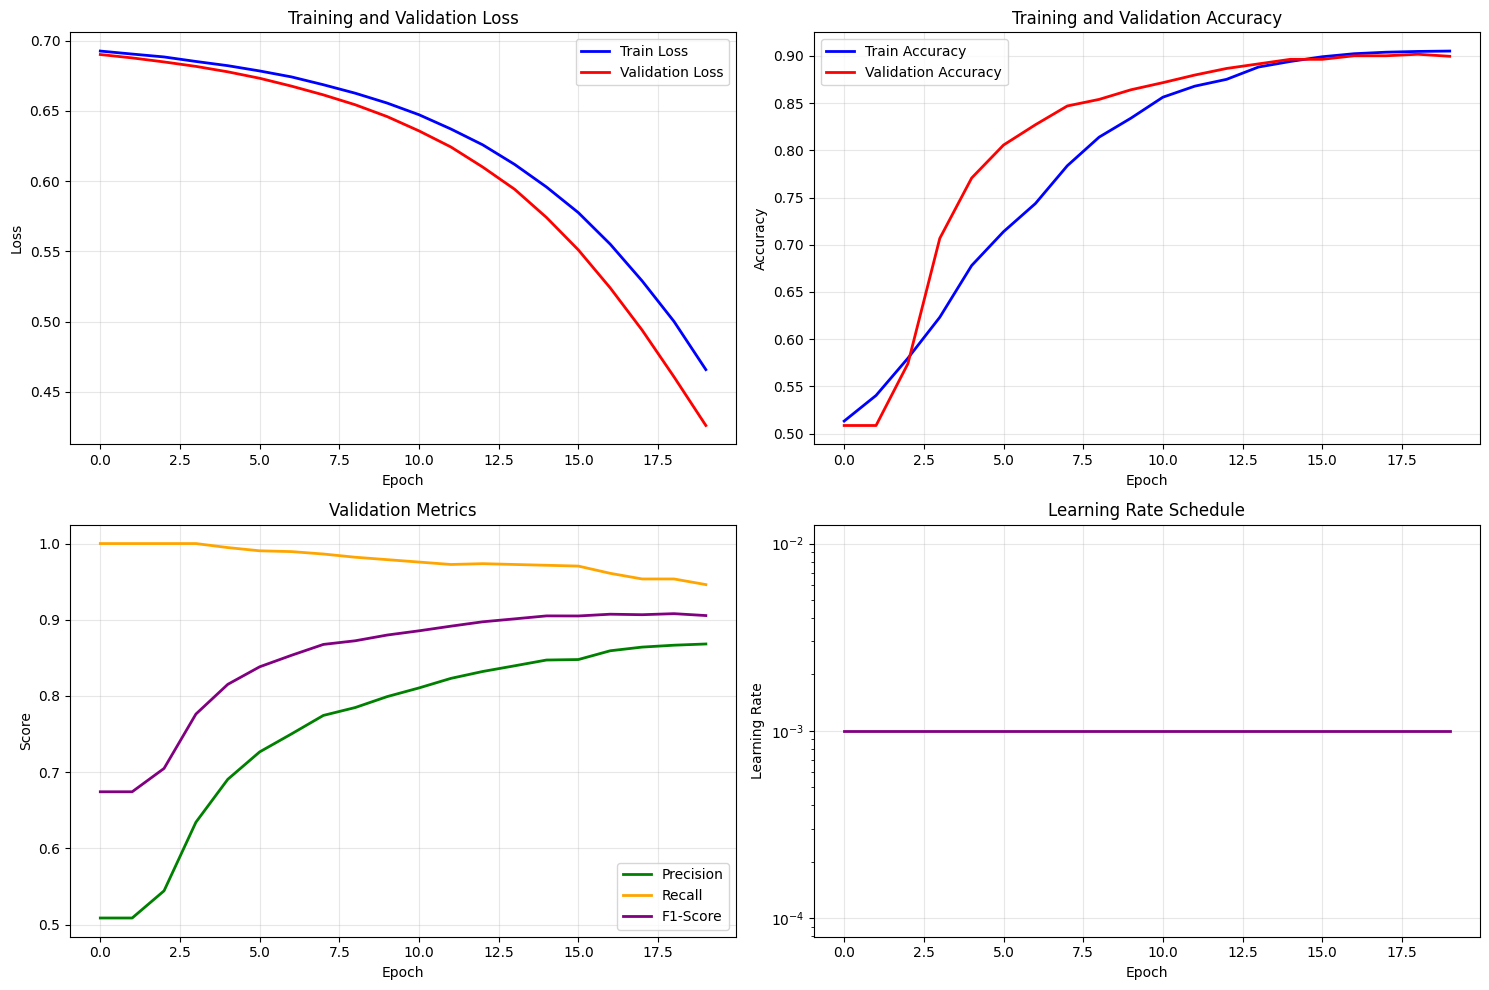

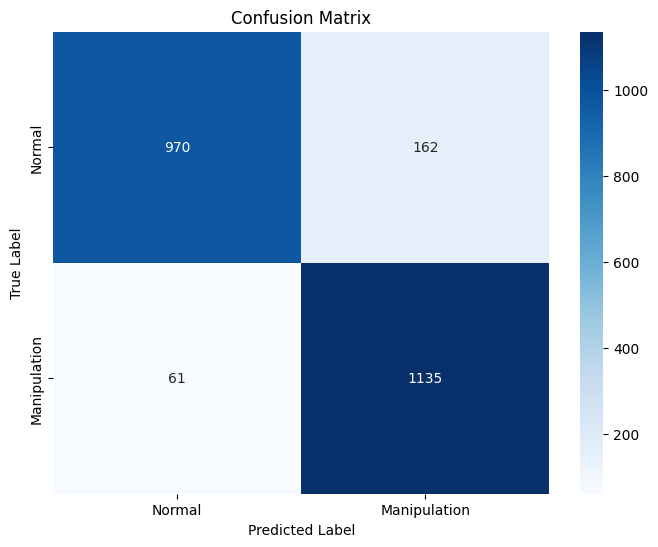

In [42]:
# Step 3: Evaluate model
evaluation_results = evaluate_model(
    trained_model, dataset_splits['test'], verbose=True
)
# Step 4: Generate visualizations
plot_training_history(training_history)
plot_confusion_matrix(evaluation_results['true_labels'], evaluation_results['predicted_classes'])
    
# Step 5: Return comprehensive results
results = {
    'model': trained_model,
    'training_history': training_history,
    'evaluation_results': evaluation_results,
    'dataset_info': dataset_splits['info']
    }